#**ASSIGNMENT 2: Inferential Statistics**

###**SECTION 1: Data Understanding**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [4]:
import pandas as pd
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('Titanic-Dataset.csv')   # change file name if needed

# Display shape
print("Shape of dataset:", df.shape)

# Display columns
print("Columns:", df.columns)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Data types
print("\nData Types:\n", df.dtypes)

Shape of dataset: (891, 12)
Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


1. Which columns have missing values?
* Columns like Age, Cabin, Embarked usually have missing values.
* Cabin has the highest missing data.

2. What type of variables are present?
* Numerical: Age, Fare, SibSp, Parch
* Categorical: Sex, Embarked, Pclass
* Binary: Survived (0 or 1)

###**SECTION 2: Sampling**

In [6]:
# Take sample
sample = df.sample(n=100, random_state=42)

# Population mean
population_mean = df['Age'].mean()

# Sample mean
sample_mean = sample['Age'].mean()

print("Population Mean:", population_mean)
print("Sample Mean:", sample_mean)

Population Mean: 29.69911764705882
Sample Mean: 29.60843373493976


1. Are sample and population mean equal?
* No, they are not exactly equal.
* They are approximately similar.

2. Why do we use sampling?
* Reduces computation time
* Saves cost and effort
* Useful when dataset is very large
* Helps estimate population characteristics

###**SECTION 3: Central Limit Theorem (CLT)**

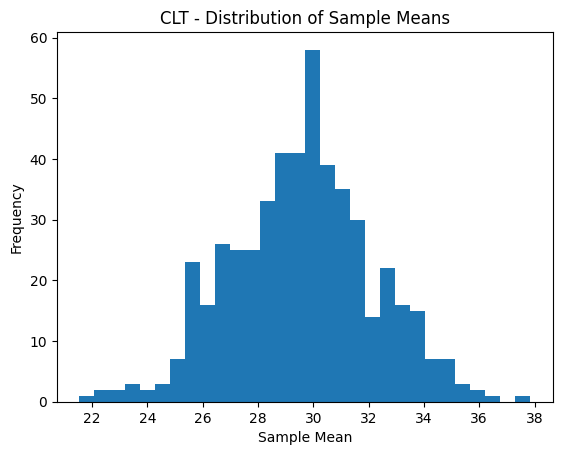

In [7]:
import matplotlib.pyplot as plt

sample_means = []

for i in range(500):
    sample = df['Age'].dropna().sample(n=30)
    sample_means.append(sample.mean())

# Plot histogram
plt.hist(sample_means, bins=30)
plt.title("CLT - Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

1. Does distribution look normal?
* Yes, it appears approximately normal (bell-shaped).

2. Why does this happen?
* Due to the Central Limit Theorem, regardless of population distribution:
* The sample mean distribution becomes normal when sample size is lar

###**SECTION 4: Confidence Interval**

In [8]:
from scipy import stats

# Drop missing values
age_data = df['Age'].dropna()

# Sample mean & std
mean = age_data.mean()
std = age_data.std()
n = len(age_data)

# 95% Confidence Interval
confidence = 0.95
z = stats.norm.ppf(0.975)

margin_error = z * (std / np.sqrt(n))

lower = mean - margin_error
upper = mean + margin_error

print("95% Confidence Interval:", (lower, upper))

95% Confidence Interval: (np.float64(28.633601847600097), np.float64(30.764633446517543))


1. What does the interval represent?
* It means we are 95% confident that the true population mean lies within this range.

2. What happens if sample size increases?
* Confidence interval becomes narrower (more precise).

###**SECTION 5: Hypothesis Testing**

In [9]:
from scipy import stats

male = df[df['Sex'] == 'male']['Survived']
female = df[df['Sex'] == 'female']['Survived']

t_stat, p_value = stats.ttest_ind(male, female)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -19.297816550123354
P-Value: 1.4060661308802594e-69


####**Decision Rule**

In [10]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


1. What is p-value?
* It is the probability that the observed result occurred by chance.
* Lower p-value = stronger evidence against H₀.

2. Conclusion
* If p < 0.05 → gender affects survival
* If p > 0.05 → no strong evidence

###**SECTION 6: Real-World Interpretation**

1. Did gender affect survival?
* Yes, generally females had higher survival rates.

2. Can we trust this conclusion?
* Yes, if:
p-value < 0.05
* sample is unbiased

3. What assumptions are we making?
* Data is randomly sampled
* Groups are independent
* Data is approximately normally distributed

4. Real-world use
* Helps in:
Policy making
Risk prediction
Emergency planning (e.g., rescue priority)

###**SECTION 7: BONUS (Passenger Class vs Survival)**

**Test: “Does passenger class affect survival?” Use hypothesis testing again**

In [11]:
# Group survival by class
class1 = df[df['Pclass'] == 1]['Survived']
class2 = df[df['Pclass'] == 2]['Survived']
class3 = df[df['Pclass'] == 3]['Survived']

# ANOVA Test
f_stat, p_value = stats.f_oneway(class1, class2, class3)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Passenger class affects survival")
else:
    print("No significant effect")

F-Statistic: 57.96481759091002
P-Value: 2.183247415118226e-24
Passenger class affects survival


Answer:
* If p < 0.05 → Passenger class significantly affects survival

* Higher class passengers had better survival chances